# Exercise: The Higgs Boson Discovery

**The Scenario:**
It is 2012. You are a particle physicist at CERN analyzing data from the Large Hadron Collider. You are searching for the elusive Higgs boson, which theory predicts should decay into pairs of photons. You have just collected your first dataset.

**The Data:**
You are given a dataset containing the invariant mass of photon pairs measured by your detector, ranging from 100 GeV to 150 GeV. The histogram below shows the real data you collected! Your task is to use this spectrum to claim a discovery and measure the mass of the new particle.

**Part 1: Hypothesis Testing via Sideband Fit**
To claim a discovery, you must first estimate the expected number of background events that fall inside the expected signal region, in order to show that the observed data is inconsistent with background-only fluctuations.

Standard Model background processes are known to produce a smoothly falling exponential distribution: $f(m) \propto e^{-\lambda m}$. You decide to look for the Higgs in the **Signal Region: [120, 130] GeV**.

1.  **Create the Sideband Dataset:** Create a "sideband" dataset by masking out all events that fall inside the [120, 130] GeV signal window.
2.  **Fit the Background Shape:** Use `iminuit` and `UnbinnedNLL` to fit the decay parameter $\lambda$ using *only* your sideband data.
    * *N.B.: You must take care to normalise the background PDF in the sideband region: the PDF integral over the two sidebands should be normalised to 1.*
3.  **The Hypothesis Test:**
    * Using your fitted value $\hat{\lambda}$, calculate the expected number of background events ($b$) that should have landed *inside* the [120, 130] GeV signal window. (Hint: This is the total number of events in the sideband multiplied by the ratio of the integrals of the PDF over the signal and sideband regions.)
    * Count the actual number of observed events ($N_{obs}$) that fall inside the signal window.
    * Calculate the Poisson p-value of observing $N_{obs}$ or more events given the expected background $b$. Do you claim a discovery of the Higgs boson with a significance of at least $5\sigma$?



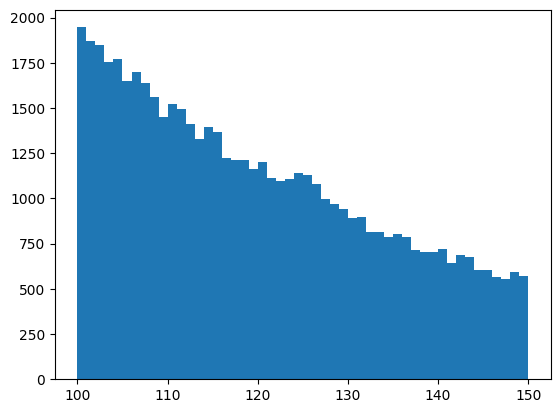

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The modified Google Drive direct-download link
# url = 'https://drive.google.com/uc?export=download&id=1AauqtqMTm5MT4b57NHOnxytsJgBSvhGX'

# df = pd.read_csv(url)
# df.to_csv('Week2_dataset.csv', index=False)


df = pd.read_csv("Week2_dataset.csv")
data = np.array(df['mass_gev'])



plt.hist(data, bins=50, range=(100, 150));


In [59]:
from iminuit.cost import UnbinnedNLL
from iminuit import Minuit
from scipy.stats import norm, expon

sig_min = 120
sig_max = 130

min_data = min(data)
max_data = max(data)

bg_data_1 = data[(data < 120)]
bg_data_2 = data[(data > 130)]

bg_data = np.array([] , dtype=np.float64)
bg_data = np.concatenate((bg_data_1, bg_data_2))
def bg_pdf( x , tau):
    exp = expon( loc = 0 , scale = tau)
    pdf = exp.pdf( x )
    normalization = -(exp.cdf( min_data ) - exp.cdf( sig_min ) + exp.cdf( sig_max ) - exp.cdf(max_data))

    
    return pdf/normalization


b = UnbinnedNLL( bg_data , bg_pdf)

bg = Minuit(b , tau = 38)
bg.limits["tau"] = (0 , None)
bg.migrad()
display(bg)


tau = bg.values["tau"]

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.222e+05                  │              Nfcn = 17               │
│ EDM = 1.13e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ tau  │   38.9    │    0.5    │            │            │    0    │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬───────┐
│     │   tau │
├─────┼───────┤
│ tau │ 0.225 │
└─────┴───────┘

In [ ]:
bg_model = expon( loc = 0 , scale = tau)

rate = (bg_model.cdf(sig_max) - bg_model.cdf(sig_min))/(-bg_model.cdf(min_data) + bg_model.cdf(max_data))

n_expected = int(np.round(len(data) * rate))

n_signal = len(data) - len(bg_data)


from scipy.stats import poisson

p_val = poisson.sf( n_signal , mu= n_expected)

print(p_val , n_signal , n_expected)


x_plot = np.linspace()

0.00010612220348145448 10760 10381
